In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [21]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['nav_lat'].values
    lon = ds['nav_lon'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds.isel(y=y_idx, x=x_idx)

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[3]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d>

In [8]:
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12',                        
                          bbox = (-85.0, 0.0, 0.0, 80.0))

In [17]:
plt.close('all')

septembers = []
for year in range (1976, 2025):
    septembers.append(f'{year}-09-15')

marches = []
for year in range (1976, 2025):
    marches.append(f'{year}-03-15')

september_data = ds1['tos_con'].sel(time_counter=septembers, method='nearest')
march_data = ds1['tos_con'].sel(time_counter=marches, method = 'nearest')

september_data['time_counter'] = september_data['time_counter'].dt.year
march_data['time_counter'] = march_data['time_counter'].dt.year
Amplitudes = (september_data - march_data).compute()

In [18]:
Amplitudes

<xarray.DataArray 'tos_con' (time_counter: 49, y: 482, x: 341)> Size: 32MB
array([[[        nan, -2.7392712 , -2.6511383 , ..., -3.284464  ,
         -3.2079182 , -3.1614609 ],
        [        nan, -2.4722786 , -2.430107  , ..., -3.3329144 ,
         -3.2549248 , -3.2105465 ],
        [        nan, -2.307293  , -2.2680721 , ..., -3.3547688 ,
         -3.3015919 , -3.2565517 ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan, -3.4443417 , -3.338684  , ..., -3.5108852 ,
         -3.5443974 , -3.5747814 ],
        [        nan, -3.2826672 , -3.139946  , ..., -3.3913784 ,
         -3.435051  , -3.4545116 ],
        [        nan, -3.078598  , -2.9541683 , ..., -3.2577057 ,
         -3.2730465 , -3.2917347 ],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan, -1.7038879 , -1.6881752 , ..., -4.0388336 ,
         -4.0246696 , -4.0118237 ],
        [        nan, -1.3433475 , -1.3228416 , ..., -3.9972076 ,
         -4.0065117 , -4.0052643 ],
        [        nan, -1.1735783 , -1.1280975 , ..., -3.9841537 ,
         -3.985632  , -3.983572  ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(49, 482, 341), dtype=float32)
Coordinates:
    nav_lon       (y, x) float64 1MB -85.0 -84.75 -84.5 ... 48.28 48.54 48.79
    nav_lat       (y, x) float64 1MB 0.0 0.0 0.0 0.0 ... 79.51 79.41 79.3 79.2
  * time_counter  (time_counter) int64 392B 1976 1977 1978 ... 2022 2023 2024
Dimensions without coordinates: y, x

x index = 23
y index = 297


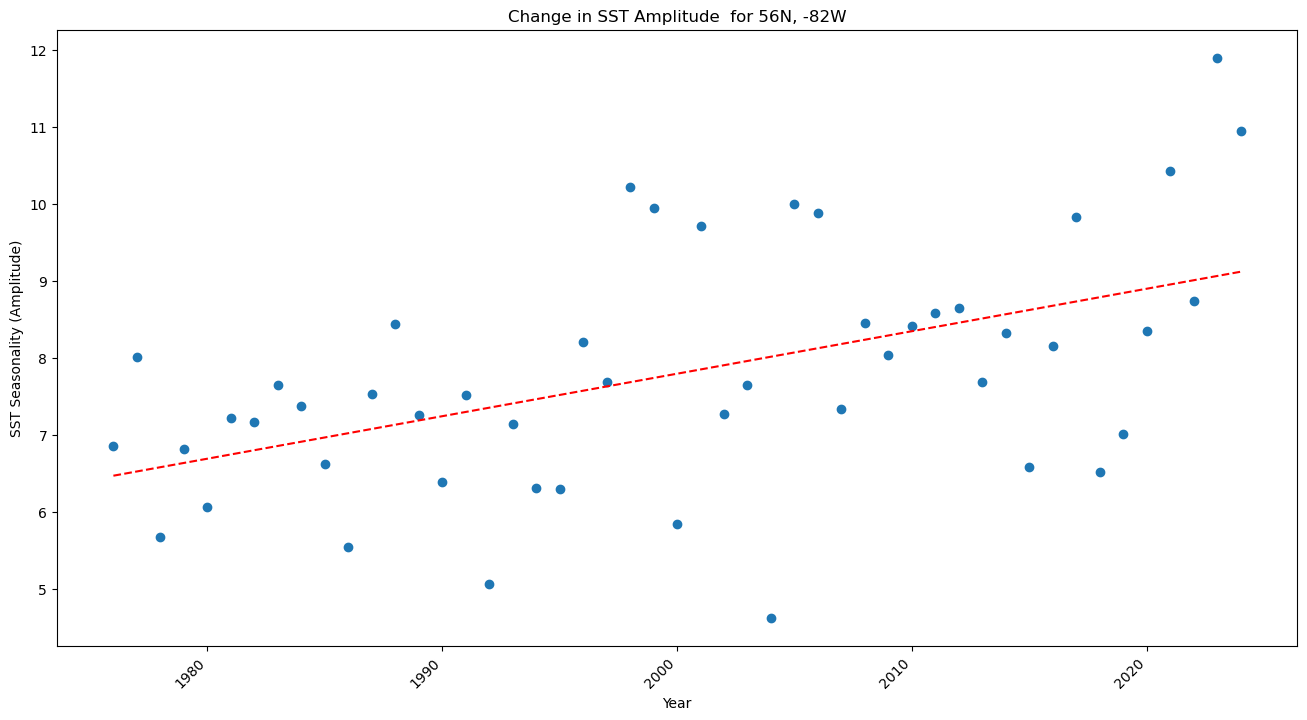

In [27]:
random_point = select_by_latlon(Amplitudes, 56.0, -82.0)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point['time_counter'], random_point.values)

z = np.polyfit(random_point['time_counter'], random_point.values, 1)
p = np.poly1d(z)
ax.plot(random_point['time_counter'] ,p(random_point['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 56N, -82W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 256
y index = 291


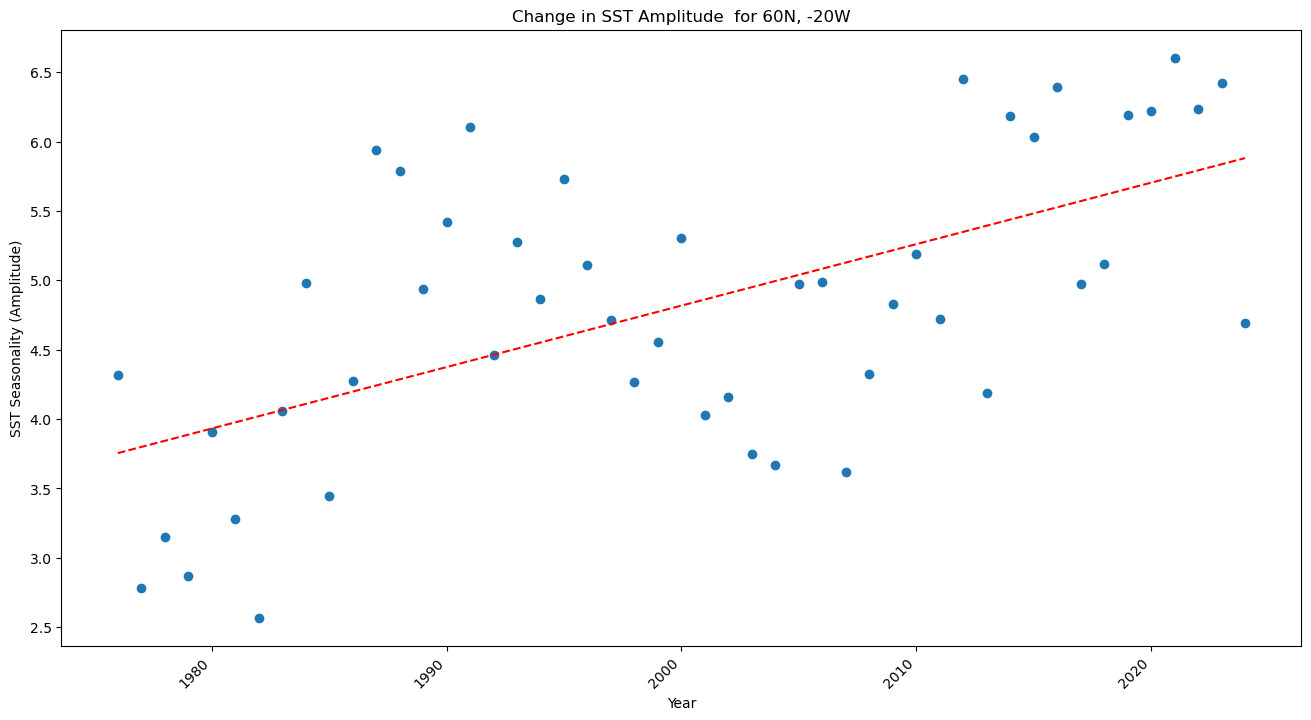

In [29]:
random_point2 = select_by_latlon(Amplitudes, 60, -20)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point2['time_counter'], random_point2.values)

z = np.polyfit(random_point2['time_counter'], random_point2.values, 1)
p = np.poly1d(z)
ax.plot(random_point2['time_counter'] ,p(random_point2['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 60N, -20W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 180
y index = 82


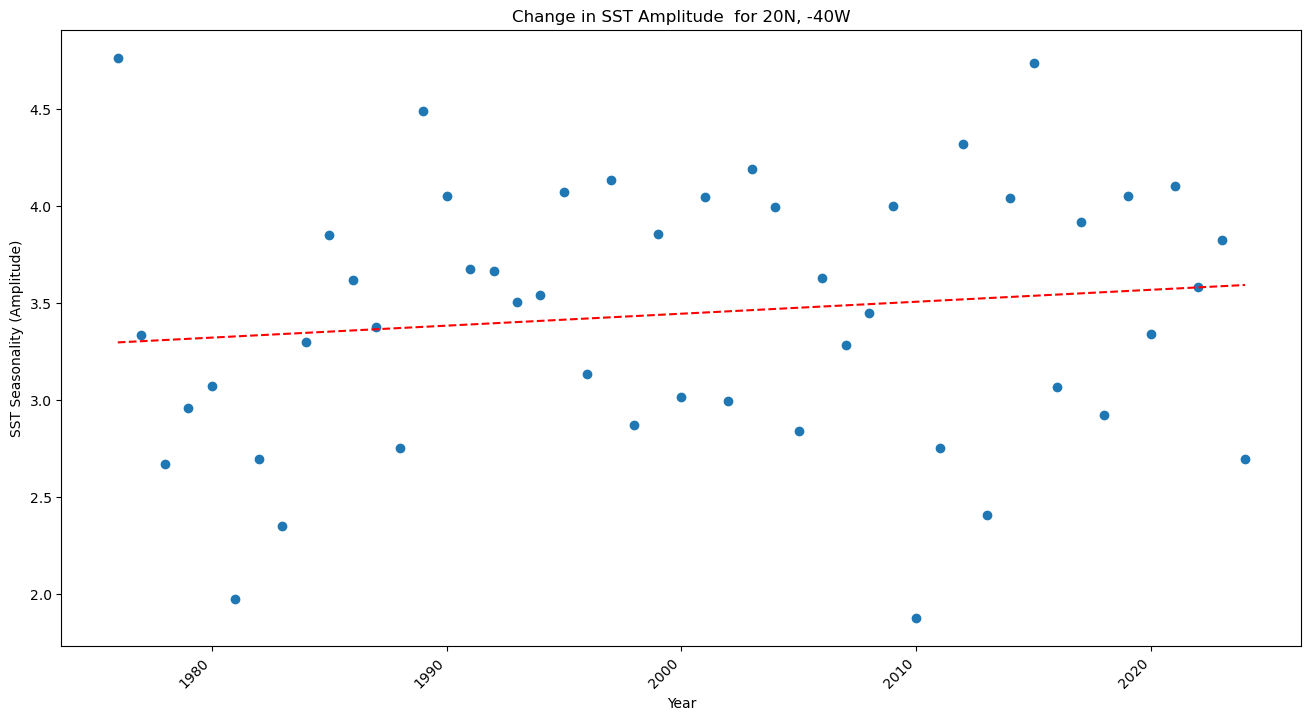

In [30]:
random_point3 = select_by_latlon(Amplitudes, 20, -40)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point3['time_counter'], random_point3.values)

z = np.polyfit(random_point3['time_counter'], random_point3.values, 1)
p = np.poly1d(z)
ax.plot(random_point3['time_counter'] ,p(random_point3['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 20N, -40W')
plt.xticks(rotation=45, ha='right')
plt.show()

x index = 141
y index = 191


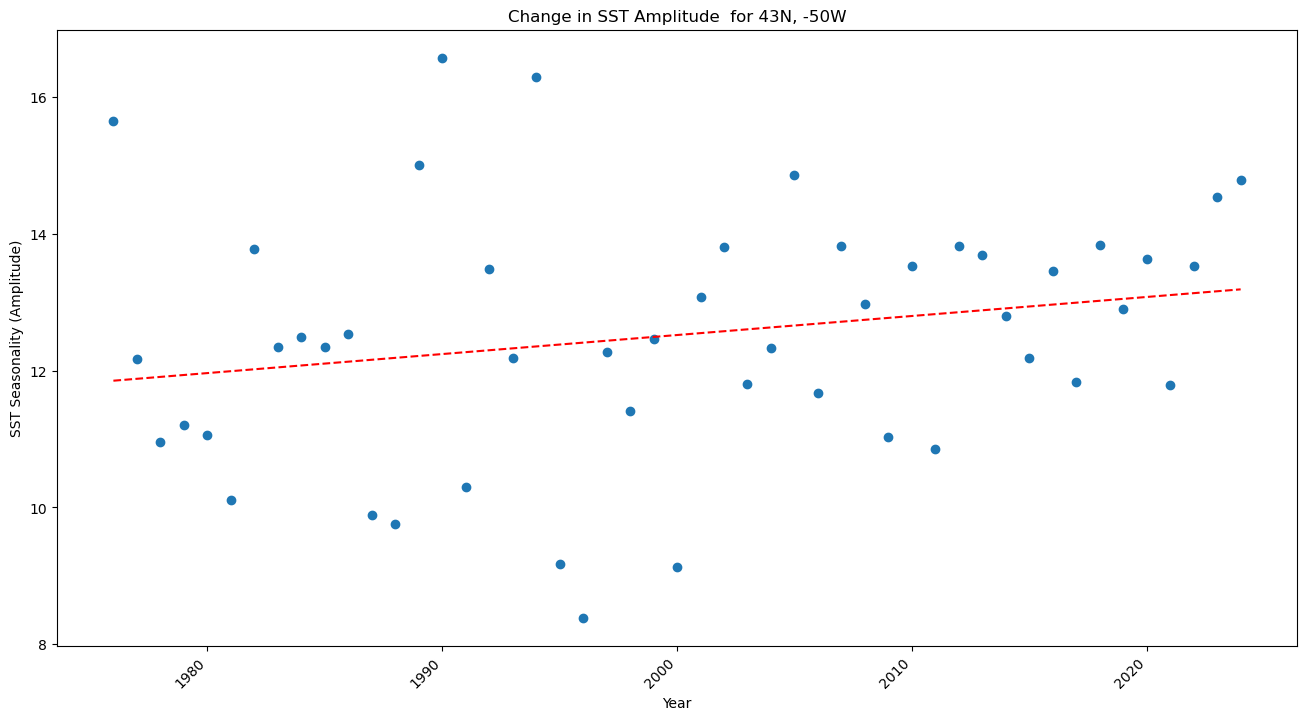

In [31]:
random_point4 = select_by_latlon(Amplitudes, 43.0, -50.0)

fig, ax = plt.subplots(figsize = (16,8))
ax.scatter(random_point4['time_counter'], random_point4.values)

z = np.polyfit(random_point4['time_counter'], random_point4.values, 1)
p = np.poly1d(z)
ax.plot(random_point4['time_counter'] ,p(random_point4['time_counter']),"r--")

ax.set_xlabel('Year')
ax.set_ylabel('SST Seasonality (Amplitude)')
ax.set_title('Change in SST Amplitude  for 43N, -50W')
plt.xticks(rotation=45, ha='right')
plt.show()

In [42]:
## Calculating map of trend magnitudes 

ny, nx = Amplitudes.sizes['y'], Amplitudes.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = Amplitudes.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['time_counter'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan
    print(y_idx)

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": Amplitudes['y'],
        "x": Amplitudes['x'],
        "nav_lat": (("y", "x"), Amplitudes['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST amplitude"})
        

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [43]:
trend_da

<xarray.DataArray 'trend' (y: 482, x: 341)> Size: 657kB
array([[        nan,  0.01304874,  0.01210364, ..., -0.00605016,
        -0.00602501, -0.00576936],
       [        nan,  0.0123802 ,  0.01169134, ..., -0.00464304,
        -0.004557  , -0.00423638],
       [        nan,  0.01125167,  0.01082038, ..., -0.00320466,
        -0.00308712, -0.0027343 ],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(482, 341), dtype=float32)
Coordinates:
  * y        (y) int64 4kB 0 1 2 3 4 5 6 7 8 ... 474 475 476 477 478 479 480 481
  * x        (x) int64 3kB 0 1 2 3 4 5 6 7 8 ... 333 334 335 336 337 338 339 340
    nav_lat  (y, x) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 79.51 79.41 79.3 79.2
    nav_lon  (y, x) float64 1MB -85.0 -84.75 -84.5 -84.25 ... 48.28 48.54 48.79
Attributes:
    description:  Linear trend over time of SST amplitude

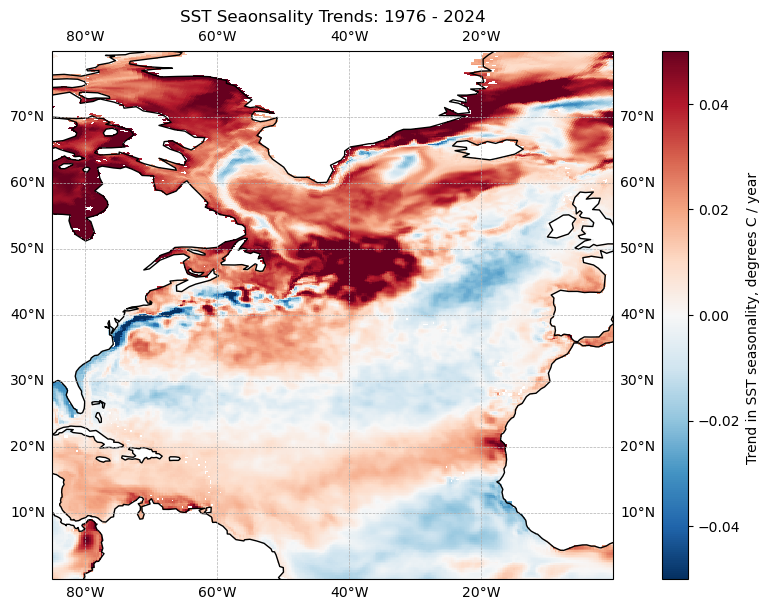

In [44]:
## Plotting Map of Trend Magnitude

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.05, vmax=0.05)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
plt.colorbar(im, ax=ax, label='Trend in SST seasonality, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Seaonsality Trends: 1976 - 2024')